In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

In [8]:
import sys
sys.path.insert(0, './MUSE')


In [9]:
def load_embeddings(emb_type="w2v"):
    en = torch.load(f"./embeddings/{emb_type}/aligned/vectors-en.pth", weights_only=False)
    fr = torch.load(f"./embeddings/{emb_type}/aligned/vectors-fr.pth", weights_only=False)
    return {
        "en_words": en["dico"],
        "en_vecs": en["vectors"].cpu().numpy(),
        "fr_words": fr["dico"],
        "fr_vecs": fr["vectors"].cpu().numpy()
    }

In [10]:
emb = load_embeddings("w2v")
print(f'Loaded: {len(emb["en_words"])} EN words, {len(emb["fr_words"])} FR words')

Loaded: 2079 EN words, 2346 FR words


In [11]:
def cosine_sim(word1, word2, emb):
    """Compute similarity between English word1 and French word2"""
    try:
        idx1 = emb['en_words'].index(word1)
        idx2 = emb['fr_words'].index(word2)
        vec1 = emb['en_vecs'][idx1].reshape(1, -1)
        vec2 = emb['fr_vecs'][idx2].reshape(1, -1)
        return cosine_similarity(vec1, vec2)[0][0]
    except:
        return None

In [22]:
# Test
pairs = [('cat', 'chat'), ('dog', 'chien'), ('house', 'maison'), 
         ('car', 'voiture'), ('book', 'livre')]

for en, fr in pairs:
    sim = cosine_sim(en, fr, emb)
    print(f"{en} vs {fr} cosine sim: {sim:.3f}" if sim else f"{en} or    {fr}: not found")

cat vs chat cosine sim: 0.997
dog vs chien cosine sim: 0.997
house vs maison cosine sim: 0.994
car vs voiture cosine sim: 0.989
book vs livre cosine sim: 0.979


In [26]:
def plot_pca(emb, word_pairs, title="PCA Visualization"):
    """Plot PCA for word pairs embeddings"""
    en_words, fr_words = [], []
    en_vecs, fr_vecs = [], []
    
    # Collect vectors
    for en_word, fr_word in word_pairs:
        if en_word in emb["en_words"] and fr_word in emb["fr_words"]:
            en_idx = emb["en_words"].index(en_word)
            fr_idx = emb["fr_words"].index(fr_word)
            
            en_words.append(en_word)
            fr_words.append(fr_word)
            en_vecs.append(emb["en_vecs"][en_idx])
            fr_vecs.append(emb["fr_vecs"][fr_idx])
    
    # Combine and reduce to 2D
    all_vecs = np.vstack([en_vecs, fr_vecs])
    pca = PCA(n_components=2, random_state=42)
    coords_2d = pca.fit_transform(all_vecs)
    
    # Split back
    n_en = len(en_words)
    en_coords = coords_2d[:n_en]
    fr_coords = coords_2d[n_en:]
    
    # Plot
    plt.figure(figsize=(10, 8))
    plt.scatter(en_coords[:, 0], en_coords[:, 1], c='blue', label='English')
    plt.scatter(fr_coords[:, 0], fr_coords[:, 1], c='red', label='French')
    
    # Labels
    for i, word in enumerate(en_words):
        plt.annotate(word, (en_coords[i, 0], en_coords[i, 1]))
    
    for i, word in enumerate(fr_words):
        plt.annotate(word, (fr_coords[i, 0], fr_coords[i, 1]))
    
    plt.legend()
    plt.title(title)
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

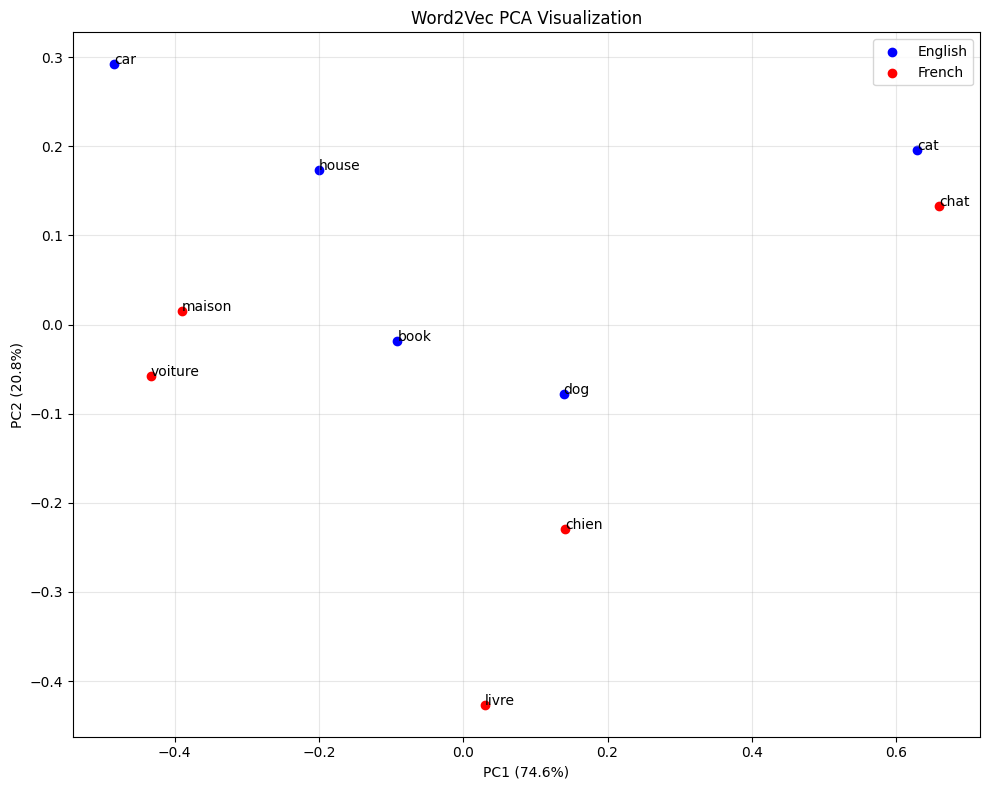

In [27]:
# Plot
plot_pca(emb, pairs, title="Word2Vec PCA Visualization")